In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import pickle

# Load cleaned data
df = pd.read_csv(r'C:\Users\kanna\hospital-readmission-predictor\data\cleaned_data.csv')

# Load best model
with open(r'C:\Users\kanna\hospital-readmission-predictor\data\best_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Load feature names
with open(r'C:\Users\kanna\hospital-readmission-predictor\data\feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

print("Model and data loaded successfully")
print(f"Features: {len(feature_names)}")

Model and data loaded successfully
Features: 45


In [2]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Encode categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != 'readmitted']

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Split data
X = df.drop(columns=['target', 'readmitted', 'patient_nbr', 'encounter_id'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data prepared: {X_test.shape}")

Data prepared: (13995, 45)


In [3]:
# Create SHAP explainer
print("Calculating SHAP values (this may take a minute)...")

explainer = shap.LinearExplainer(model, X_train)
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated successfully!")
print(f"Shape of SHAP values: {shap_values.shape}")

Calculating SHAP values (this may take a minute)...
SHAP values calculated successfully!
Shape of SHAP values: (13995, 45)


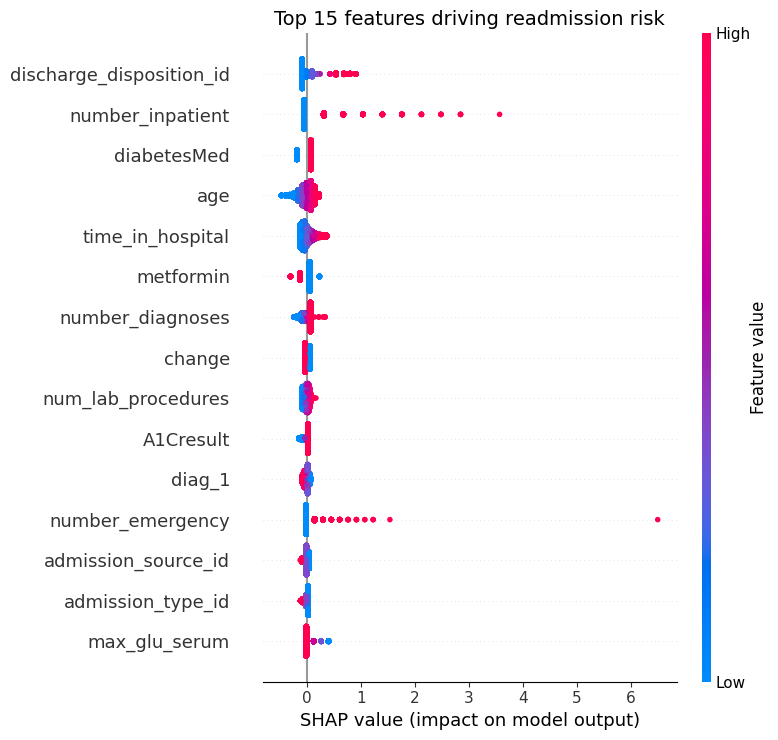

SHAP summary plot saved!


In [4]:
# Plot 1: SHAP Summary Plot (global feature importance)
plt.figure()
shap.summary_plot(
    shap_values, 
    X_test, 
    feature_names=feature_names,
    max_display=15,
    show=False
)
plt.title('Top 15 features driving readmission risk', fontsize=14)
plt.tight_layout()
plt.savefig(r'C:\Users\kanna\hospital-readmission-predictor\data\shap_summary.png', 
            bbox_inches='tight', dpi=150)
plt.show()
print("SHAP summary plot saved!")

Generating explanation for highest risk patient...


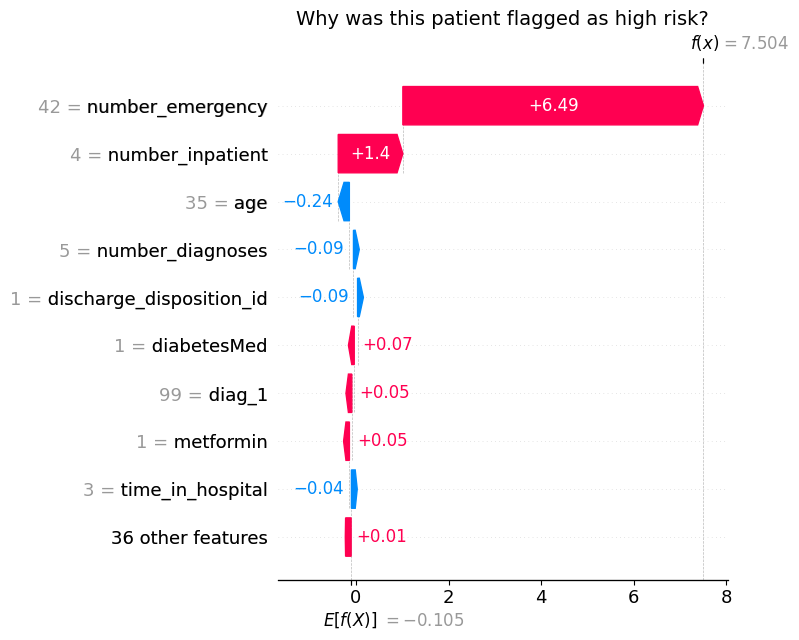

Waterfall plot saved!


In [5]:
# Plot 2: SHAP Waterfall Plot (single patient explanation)
print("Generating explanation for highest risk patient...")

# Find the highest risk patient
highest_risk_idx = shap_values.sum(axis=1).argmax()

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[highest_risk_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[highest_risk_idx],
        feature_names=feature_names
    ),
    show=False
)
plt.title('Why was this patient flagged as high risk?', fontsize=14)
plt.tight_layout()
plt.savefig(r'C:\Users\kanna\hospital-readmission-predictor\data\shap_waterfall.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Waterfall plot saved!")

In [6]:
# Save SHAP summary as text for LinkedIn article
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'mean_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_shap', ascending=False)

print("=== Top 10 Most Important Features ===")
print(feature_importance.head(10).to_string(index=False))

feature_importance.to_csv(
    r'C:\Users\kanna\hospital-readmission-predictor\data\feature_importance.csv',
    index=False
)
print("\nSaved to feature_importance.csv")

=== Top 10 Most Important Features ===
                 feature  mean_shap
discharge_disposition_id   0.118802
        number_inpatient   0.102792
             diabetesMed   0.099671
                     age   0.097129
        time_in_hospital   0.083871
               metformin   0.069983
        number_diagnoses   0.066684
                  change   0.041535
      num_lab_procedures   0.033402
               A1Cresult   0.029532

Saved to feature_importance.csv
